In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import class_weight

from lightgbm import LGBMClassifier
import seaborn as sns
import matplotlib.pyplot as plt

In this phase, the proposed methodology was compared with recent research work to identify potential gaps. Based on this analysis, improvements were made to enhance model performance, handle limitations, and make the approach more robust for IoT attack classification.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/malaikatanveer123/feature-engineered-iot-dataset/feature_engineered_iot_dataset.csv")

df.head()

,src_port,dst_port,conn_state,label,type,dst_ip_bytes_log,src_ip_bytes_log,duration_log,dst_bytes_log,src_bytes_log,bytes_ratio,ip_bytes_ratio,pkts_ratio,total_ip_bytes,bytes_per_pkt,bytes_per_second,port_sum,port_diff,cluster
0,-1.771488,4.482402,-1.445311,1,0,1.688084,3.589469,5.831540,1.861587,3.780154,0.519731,-0.450308,-0.049654,3.117916,0.867043,-0.007275,0.575585,0.360179,0
1,0.545572,0.449865,-1.194698,1,0,0.162709,-0.364782,-0.339676,-0.612359,-0.699019,-0.426069,-0.622781,0.268547,-0.057173,-0.721726,-0.675697,0.757982,0.163125,2
2,0.545572,0.449865,-1.194698,1,0,0.162709,-0.364782,-0.339626,-0.612359,-0.699019,-0.426069,-0.622781,0.268547,-0.057173,-0.721726,-0.675697,0.757982,0.163125,2
3,0.545572,0.449865,-1.194698,1,0,0.162709,-0.405503,-0.339664,-0.612359,-0.699019,-0.426069,-0.629775,0.268547,-0.077666,-0.721726,-0.675697,0.757982,0.163125,2
4,0.545572,0.449865,-1.194698,1,0,0.162709,-0.364782,-0.339645,-0.612359,-0.699019,-0.426069,-0.622781,0.268547,-0.057173,-0.721726,-0.675697,0.757982,0.163125,2


In [8]:
X = df.drop(['type','label'], axis=1)
y = df['type']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(zip(np.unique(y_train), class_weights))

print(class_weights_dict)

{np.int64(0): np.float64(1.0498973944406442), np.int64(1): np.float64(1.0595167869469722), np.int64(2): np.float64(1.0508776297771691), np.int64(3): np.float64(1.053763575084259), np.int64(4): np.float64(20.34144578313253), np.int64(5): np.float64(0.4223067110232872), np.int64(6): np.float64(1.0531062874251498), np.int64(7): np.float64(1.058321318874193), np.int64(8): np.float64(1.0562026900218955), np.int64(9): np.float64(1.0584540154222306)}


One major limitation identified in the initial methodology was class imbalance, where some attack categories had significantly fewer samples than others. This imbalance negatively affects model performance, especially for minority classes.

To address this issue, class weights were computed and applied during model training. This ensures that the model gives more importance to underrepresented classes, improving recall and overall classification performance for those attack types.

In [11]:
lgb = LGBMClassifier(class_weight=class_weights_dict)

lgb.fit(X_train, y_train)

y_pred = lgb.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3791
[LightGBM] [Info] Number of data points in the train set: 168834, number of used features: 17
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585


The LightGBM model was retrained using class weights to improve its ability to generalize across all attack categories. This enhancement helps the model better learn patterns from imbalanced data and reduces bias toward majority classes.

In [12]:
print("Improved LightGBM Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Improved LightGBM Accuracy: 0.9887464758700751
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3919
           1       0.99      0.98      0.98      4065
           2       0.99      0.98      0.99      3934
           3       0.98      0.97      0.97      3978
           4       0.60      0.90      0.72       213
           5       1.00      0.99      1.00     10021
           6       1.00      0.99      0.99      3968
           7       1.00      1.00      1.00      4047
           8       0.99      0.99      0.99      4015
           9       0.97      0.99      0.98      4049

    accuracy                           0.99     42209
   macro avg       0.95      0.98      0.96     42209
weighted avg       0.99      0.99      0.99     42209



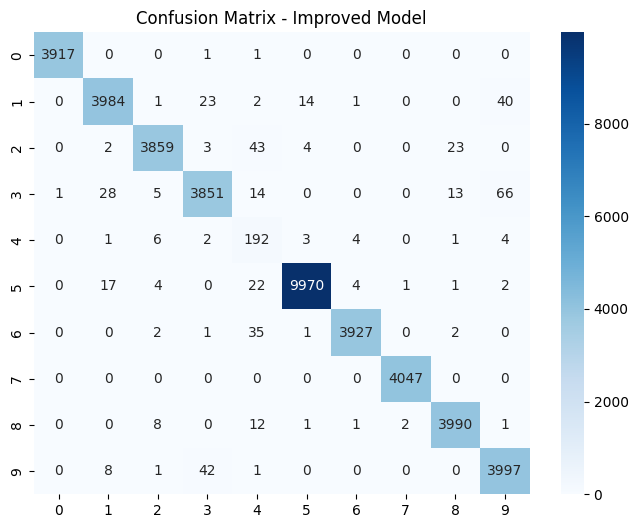

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Improved Model")
plt.show()

In [14]:
importance = pd.Series(lgb.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

importance.head(15)

duration_log        3899
src_port            3020
port_diff           2481
port_sum            2451
dst_port            2440
src_ip_bytes_log    2091
dst_ip_bytes_log    1584
bytes_per_second    1498
total_ip_bytes      1481
ip_bytes_ratio      1443
dst_bytes_log       1333
conn_state          1324
src_bytes_log       1324
bytes_per_pkt       1297
bytes_ratio         1278
dtype: int32

Another limitation observed was the presence of less important features, which could introduce noise and reduce model efficiency.

To overcome this, feature importance analysis was used to select the top 15 most important features. By training the model on these selected features, the dimensionality of the dataset was reduced, leading to improved performance, faster training, and better generalization.

In [16]:
top_features = importance.head(15).index

X_top = df[top_features]
y = df['type']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_top, y, test_size=0.2, random_state=42
)

lgb2 = LGBMClassifier(class_weight=class_weights_dict)

lgb2.fit(X_train, y_train)

y_pred2 = lgb2.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005573 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3584
[LightGBM] [Info] Number of data points in the train set: 168834, number of used features: 15
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585


After applying class imbalance handling and feature selection, the model was retrained and evaluated again. The improved model showed better performance, particularly in detecting minority attack classes, while maintaining high overall accuracy.

In [18]:
print("Final Model Accuracy:", accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))

Final Model Accuracy: 0.9889833921675472
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3919
           1       0.99      0.98      0.98      4065
           2       0.99      0.98      0.99      3934
           3       0.98      0.97      0.98      3978
           4       0.61      0.92      0.73       213
           5       1.00      1.00      1.00     10021
           6       1.00      0.99      0.99      3968
           7       1.00      1.00      1.00      4047
           8       0.99      0.99      0.99      4015
           9       0.97      0.99      0.98      4049

    accuracy                           0.99     42209
   macro avg       0.95      0.98      0.96     42209
weighted avg       0.99      0.99      0.99     42209



The IoT Attack Risk Indicator was further improved using the optimized model. This allows the system to not only detect whether traffic is malicious but also predict the specific type of attack more accurately, providing deeper insights into network threats.

In [19]:
df['attack_risk'] = lgb2.predict(X_top)

Most existing research focuses on either binary classification or does not effectively handle class imbalance and feature redundancy. In contrast, this work addresses these gaps by:

- Performing multi-class classification of IoT attacks  
- Applying feature engineering and feature selection  
- Handling class imbalance using class weights  
- Providing an interpretable IoT Attack Risk Indicator  

These improvements make the proposed methodology more practical and effective for real-world IoT security applications.

In [20]:
df.to_csv("final_improved_iot_dataset.csv", index=False)

The improved methodology successfully enhances the performance and robustness of the IoT attack classification system. By addressing key limitations such as class imbalance and irrelevant features, the model becomes more accurate and reliable in detecting various types of cyber attacks.